# WESAD — Improved Raw Time-Series Models

This notebook compares **five** deep learning architectures on raw wrist sensor data, using techniques identified from the literature to boost performance beyond the baseline GRU/LSTM/ResNet:

| Improvement | What changed | Why |
|-------------|-------------|-----|
| **Overlapping windows** | 60s windows with 50% overlap | More training samples, captures transitions |
| **Per-subject normalization** | Z-normalize each subject's signals before windowing | Reduces inter-subject scale differences |
| **Hybrid CNN-LSTM** | 1D-CNN front-end → LSTM back-end | CNN extracts local motifs, LSTM models temporal flow |
| **Attention layer** | Self-attention on LSTM outputs | Lets the model focus on informative time steps |
| **Multi-scale CNN** | Parallel convolutions with different kernel sizes | Captures short (heartbeat) and long (EDA drift) patterns |

All experiments use **LOSO** evaluation on 15 subjects, both **3-class** and **binary** tasks.

---
## 0 — Setup

In [1]:
import os
os.environ['TORCHDYNAMO_DISABLE'] = '1'

import pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


---
## 1 — Data Loading with Improved Preprocessing

Key changes from the baseline notebook:
- **Per-subject z-normalization** applied to each channel *before* windowing
- **60-second windows** with **50% overlap** (doubles training data vs non-overlapping)
- Resampled to a common 4 Hz across all channels

In [2]:
WESAD_ROOT = Path('data') / 'WESAD'
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

FS_WRIST = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
FS_LABEL = 700
TARGET_FS = 4

WINDOW_SEC = 60
OVERLAP = 0.5
SEQ_LEN = TARGET_FS * WINDOW_SEC  # 240 steps
STEP = int(SEQ_LEN * (1 - OVERLAP))  # 120 steps

VALID_LABELS = {1, 2, 3}
RAW_LABEL_TO_IDX = {1: 1, 2: 2, 3: 0}

N_CHANNELS = 6
MULTI_NAMES = ['Amusement', 'Baseline', 'Stress']
BIN_NAMES = ['Not-Stress', 'Stress']

print(f'Window: {WINDOW_SEC}s = {SEQ_LEN} steps @ {TARGET_FS}Hz')
print(f'Overlap: {OVERLAP*100:.0f}%  →  step = {STEP} samples')
print(f'Channels: EDA, BVP, TEMP, ACC_x, ACC_y, ACC_z = {N_CHANNELS}')

Window: 60s = 240 steps @ 4Hz
Overlap: 50%  →  step = 120 samples
Channels: EDA, BVP, TEMP, ACC_x, ACC_y, ACC_z = 6


In [3]:
def load_subject_raw(wesad_root, subject_id):
    name = f'S{subject_id}'
    pkl_path = wesad_root / name / f'{name}.pkl'
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    wrist = data['signal']['wrist']
    labels = np.asarray(data['label']).reshape(-1)
    total_sec = len(labels) / FS_LABEL
    n_target = int(total_sec * TARGET_FS)

    eda = resample(np.asarray(wrist['EDA']).reshape(-1), n_target)
    bvp = resample(np.asarray(wrist['BVP']).reshape(-1), n_target)
    temp = resample(np.asarray(wrist['TEMP']).reshape(-1), n_target)
    acc = np.asarray(wrist['ACC'])
    if acc.ndim == 1:
        acc = acc.reshape(-1, 1)
    acc_x = resample(acc[:, 0], n_target)
    acc_y = resample(acc[:, 1], n_target)
    acc_z = resample(acc[:, 2], n_target)

    label_indices = np.linspace(0, len(labels) - 1, n_target).astype(int)
    labels_resampled = labels[label_indices]

    signals = np.stack([eda, bvp, temp, acc_x, acc_y, acc_z], axis=1)

    # Per-subject z-normalization (channel-wise)
    for c in range(signals.shape[1]):
        mu = signals[:, c].mean()
        std = signals[:, c].std() + 1e-8
        signals[:, c] = (signals[:, c] - mu) / std

    return signals, labels_resampled


def segment_subject(signals, labels, seq_len, step, valid_labels, label_map):
    """Sliding-window segmentation with overlap. Majority-vote label per window."""
    X_list, y_list = [], []
    start = 0
    while start + seq_len <= len(signals):
        end = start + seq_len
        seg_labels = labels[start:end]
        vals, cnts = np.unique(seg_labels, return_counts=True)
        majority = vals[cnts.argmax()]

        if majority in valid_labels:
            X_list.append(signals[start:end])
            y_list.append(label_map[majority])

        start += step

    if len(X_list) == 0:
        return np.empty((0, seq_len, signals.shape[1])), np.empty((0,), dtype=int)
    return np.array(X_list), np.array(y_list)

In [4]:
pkl_available = all(
    (WESAD_ROOT / f'S{sid}' / f'S{sid}.pkl').exists() for sid in SUBJECT_IDS
)

if not pkl_available:
    missing = [sid for sid in SUBJECT_IDS
               if not (WESAD_ROOT / f'S{sid}' / f'S{sid}.pkl').exists()]
    print(f'Missing pkl files for subjects: {missing}')
    print(f'Place them at: {WESAD_ROOT}/S{{id}}/S{{id}}.pkl')
else:
    subject_data = {}
    for sid in SUBJECT_IDS:
        signals, labels = load_subject_raw(WESAD_ROOT, sid)
        X, y = segment_subject(signals, labels, SEQ_LEN, STEP, VALID_LABELS, RAW_LABEL_TO_IDX)
        subject_data[sid] = (X, y)
        print(f'  S{sid:>2d}: {X.shape[0]:>3d} windows  '
              f'(Amu={np.sum(y==0)}, Bas={np.sum(y==1)}, Str={np.sum(y==2)})')

    total = sum(v[0].shape[0] for v in subject_data.values())
    print(f'\nTotal windows: {total} (vs ~1178 with 30s non-overlapping)')

  S 2:  71 windows  (Amu=12, Bas=38, Str=21)
  S 3:  73 windows  (Amu=13, Bas=38, Str=22)
  S 4:  72 windows  (Amu=12, Bas=39, Str=21)
  S 5:  73 windows  (Amu=12, Bas=40, Str=21)
  S 6:  73 windows  (Amu=12, Bas=39, Str=22)
  S 7:  73 windows  (Amu=13, Bas=39, Str=21)
  S 8:  74 windows  (Amu=12, Bas=39, Str=23)
  S 9:  72 windows  (Amu=12, Bas=39, Str=21)
  S10:  75 windows  (Amu=12, Bas=39, Str=24)
  S11:  76 windows  (Amu=13, Bas=40, Str=23)
  S13:  75 windows  (Amu=13, Bas=40, Str=22)
  S14:  75 windows  (Amu=13, Bas=40, Str=22)
  S15:  75 windows  (Amu=13, Bas=39, Str=23)
  S16:  73 windows  (Amu=12, Bas=39, Str=22)
  S17:  75 windows  (Amu=12, Bas=39, Str=24)

Total windows: 1105 (vs ~1178 with 30s non-overlapping)


---
## 2 — Model Architectures

In [5]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### Model 1 — CNN-LSTM Hybrid

A 1D-CNN front-end extracts local temporal features (e.g. heartbeat morphology in BVP, phasic bursts in EDA), then an LSTM processes the resulting feature sequence to capture longer-range temporal dependencies.

In [6]:
class CNN_LSTM(nn.Module):
    def __init__(self, input_dim=6, num_classes=3, cnn_filters=64,
                 lstm_hidden=64, lstm_layers=1, dropout=0.3, **kwargs):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, cnn_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(cnn_filters, cnn_filters, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(cnn_filters, lstm_hidden, num_layers=lstm_layers,
                            batch_first=True, dropout=dropout if lstm_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x):
        # x: (batch, seq_len, channels)
        x = x.permute(0, 2, 1)       # (batch, channels, seq_len)
        x = self.cnn(x)               # (batch, cnn_filters, reduced_len)
        x = x.permute(0, 2, 1)       # (batch, reduced_len, cnn_filters)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

### Model 2 — CNN-GRU Hybrid

Same idea as CNN-LSTM but with GRU (fewer parameters, often comparable performance).

In [7]:
class CNN_GRU(nn.Module):
    def __init__(self, input_dim=6, num_classes=3, cnn_filters=64,
                 gru_hidden=64, gru_layers=1, dropout=0.3, **kwargs):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, cnn_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(cnn_filters, cnn_filters, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(cnn_filters, gru_hidden, num_layers=gru_layers,
                          batch_first=True, dropout=dropout if gru_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_hidden, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])

### Model 3 — CNN-LSTM with Self-Attention

Adds a self-attention layer after the LSTM. Instead of only using the last hidden state, attention learns which time steps are most informative for the prediction.

In [8]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden)
        scores = self.attn(lstm_out).squeeze(-1)    # (batch, seq_len)
        weights = F.softmax(scores, dim=1)           # (batch, seq_len)
        context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)  # (batch, hidden)
        return context


class CNN_LSTM_Attention(nn.Module):
    def __init__(self, input_dim=6, num_classes=3, cnn_filters=64,
                 lstm_hidden=64, lstm_layers=1, dropout=0.3, **kwargs):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, cnn_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(cnn_filters, cnn_filters, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(cnn_filters, lstm_hidden, num_layers=lstm_layers,
                            batch_first=True, dropout=dropout if lstm_layers > 1 else 0.0)
        self.attention = SelfAttention(lstm_hidden)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        context = self.attention(out)
        return self.head(context)

### Model 4 — Multi-Scale CNN-LSTM

Uses parallel 1D convolutions with kernel sizes 3, 7, and 15 to capture patterns at different temporal scales simultaneously (fast BVP oscillations vs slow EDA drift), concatenates them, then feeds into LSTM.

In [9]:
class MultiScaleCNN_LSTM(nn.Module):
    def __init__(self, input_dim=6, num_classes=3, filters_per_scale=32,
                 lstm_hidden=64, lstm_layers=1, dropout=0.3, **kwargs):
        super().__init__()
        self.branch_small = nn.Sequential(
            nn.Conv1d(input_dim, filters_per_scale, kernel_size=3, padding=1),
            nn.BatchNorm1d(filters_per_scale), nn.ReLU(),
        )
        self.branch_med = nn.Sequential(
            nn.Conv1d(input_dim, filters_per_scale, kernel_size=7, padding=3),
            nn.BatchNorm1d(filters_per_scale), nn.ReLU(),
        )
        self.branch_large = nn.Sequential(
            nn.Conv1d(input_dim, filters_per_scale, kernel_size=15, padding=7),
            nn.BatchNorm1d(filters_per_scale), nn.ReLU(),
        )
        total_filters = filters_per_scale * 3
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(total_filters, lstm_hidden, num_layers=lstm_layers,
                            batch_first=True, dropout=dropout if lstm_layers > 1 else 0.0)
        self.attention = SelfAttention(lstm_hidden)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, ch, seq)
        s = self.branch_small(x)
        m = self.branch_med(x)
        l = self.branch_large(x)
        x = torch.cat([s, m, l], dim=1)  # (batch, 3*filters, seq)
        x = self.dropout(self.pool(x))
        x = x.permute(0, 2, 1)  # (batch, seq/2, 3*filters)
        out, _ = self.lstm(x)
        context = self.attention(out)
        return self.head(context)

### Model 5 — ResNet-LSTM Hybrid

Uses residual convolutional blocks (like the baseline ResNet) as the front-end, but replaces global average pooling with an LSTM + attention back-end. This combines the stability of residual learning with temporal modelling.

In [10]:
class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.block(x))


class ResNet_LSTM(nn.Module):
    def __init__(self, input_dim=6, num_classes=3, n_filters=64,
                 n_blocks=3, lstm_hidden=64, lstm_layers=1, dropout=0.3, **kwargs):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(input_dim, n_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(n_filters), nn.ReLU(),
        )
        self.res_blocks = nn.Sequential(
            *[ResBlock(n_filters, kernel_size=7, dropout=dropout)
              for _ in range(n_blocks)]
        )
        self.pool = nn.MaxPool1d(2)
        self.lstm = nn.LSTM(n_filters, lstm_hidden, num_layers=lstm_layers,
                            batch_first=True, dropout=dropout if lstm_layers > 1 else 0.0)
        self.attention = SelfAttention(lstm_hidden)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.input_proj(x)
        x = self.res_blocks(x)
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        context = self.attention(out)
        return self.head(context)

---
## 3 — LOSO Evaluation

In [11]:
def to_binary(labels):
    return (labels == 2).astype(int)


def per_channel_standardise(X_train, X_test):
    n_ch = X_train.shape[2]
    means = np.zeros(n_ch)
    stds = np.zeros(n_ch)
    for c in range(n_ch):
        flat = X_train[:, :, c].ravel()
        means[c] = flat.mean()
        stds[c] = flat.std() + 1e-8
    return (X_train - means) / stds, (X_test - means) / stds


def loso_run(subject_data, model_class, num_classes=3, binary=False,
             lr=1e-3, epochs=80, batch_size=16, verbose_every=10, **model_kwargs):
    subjects = sorted(subject_data.keys())
    fold_metrics = []
    all_y_true, all_y_pred = [], []

    for test_subj in subjects:
        X_trains = [subject_data[s][0] for s in subjects if s != test_subj]
        y_trains = [subject_data[s][1] for s in subjects if s != test_subj]
        X_train = np.concatenate(X_trains)
        y_train = np.concatenate(y_trains)
        X_test, y_test = subject_data[test_subj]

        if binary:
            y_train, y_test = to_binary(y_train), to_binary(y_test)

        if len(X_test) == 0:
            continue

        X_train, X_test = per_channel_standardise(X_train, X_test)

        classes, counts = np.unique(y_train, return_counts=True)
        weights = torch.tensor(1.0 / counts, dtype=torch.float32)
        weights = weights / weights.sum() * len(classes)

        train_loader = DataLoader(SequenceDataset(X_train, y_train),
                                  batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(SequenceDataset(X_test, y_test),
                                 batch_size=len(X_test))

        n_cls = num_classes if not binary else 2
        model = model_class(input_dim=X_train.shape[2], num_classes=n_cls,
                            **model_kwargs).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        print(f'\n  S{test_subj} held out ...')
        model.train()
        for epoch in range(epochs):
            running_loss, running_total = 0.0, 0
            for X_b, y_b in train_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(X_b), y_b)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * X_b.size(0)
                running_total += y_b.size(0)

            epoch_loss = running_loss / running_total
            if ((epoch + 1) % verbose_every == 0) or (epoch == 0) or (epoch == epochs - 1):
                print(f'    epoch {epoch+1:>3d}/{epochs}  loss={epoch_loss:.4f}')

        model.eval()
        with torch.no_grad():
            for X_b, y_b in test_loader:
                preds = model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy()
                y_true = y_b.numpy()

        acc = accuracy_score(y_true, preds)
        f1 = f1_score(y_true, preds, average='macro')
        fold_metrics.append({'subject': test_subj, 'accuracy': acc, 'macro_f1': f1})
        all_y_true.extend(y_true)
        all_y_pred.extend(preds)
        print(f'    => acc={acc:.3f}  f1={f1:.3f}')

    mdf = pd.DataFrame(fold_metrics)
    return {
        'per_fold': mdf,
        'mean_acc': mdf['accuracy'].mean(), 'std_acc': mdf['accuracy'].std(),
        'mean_f1': mdf['macro_f1'].mean(), 'std_f1': mdf['macro_f1'].std(),
        'y_true': np.array(all_y_true), 'y_pred': np.array(all_y_pred),
    }

In [12]:
def print_results(name, res, target_names=None):
    print(f'\n{"="*60}')
    print(f' {name}')
    print(f'{"="*60}')
    print(f'  Mean Accuracy : {res["mean_acc"]:.4f} +/- {res["std_acc"]:.4f}')
    print(f'  Mean Macro-F1 : {res["mean_f1"]:.4f} +/- {res["std_f1"]:.4f}')
    print()
    print(classification_report(res['y_true'], res['y_pred'],
                                target_names=target_names, digits=3))


def plot_confusion(res, title, target_names=None):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(title)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

---
## 4 — Run All Models

In [13]:
MODELS = [
    ('CNN-LSTM',           CNN_LSTM,           dict(cnn_filters=64, lstm_hidden=64, lstm_layers=1, dropout=0.3)),
    ('CNN-GRU',            CNN_GRU,            dict(cnn_filters=64, gru_hidden=64, gru_layers=1, dropout=0.3)),
    ('CNN-LSTM-Attention', CNN_LSTM_Attention,  dict(cnn_filters=64, lstm_hidden=64, lstm_layers=1, dropout=0.3)),
    ('MultiScale-LSTM',   MultiScaleCNN_LSTM,  dict(filters_per_scale=32, lstm_hidden=64, lstm_layers=1, dropout=0.3)),
    ('ResNet-LSTM',        ResNet_LSTM,        dict(n_filters=64, n_blocks=3, lstm_hidden=64, lstm_layers=1, dropout=0.3)),
]

all_results = {}

### 4.1 — 3-Class


############################################################
# CNN-LSTM_3class
############################################################

  S2 held out ...
    epoch   1/80  loss=0.6983
    epoch  10/80  loss=0.5246
    epoch  20/80  loss=0.2923
    epoch  30/80  loss=0.2735
    epoch  40/80  loss=0.2403
    epoch  50/80  loss=0.1996
    epoch  60/80  loss=0.1208
    epoch  70/80  loss=0.1212
    epoch  80/80  loss=0.1298
    => acc=0.859  f1=0.823

  S3 held out ...
    epoch   1/80  loss=0.6779
    epoch  10/80  loss=0.3311
    epoch  20/80  loss=0.2954
    epoch  30/80  loss=0.1960
    epoch  40/80  loss=0.1945
    epoch  50/80  loss=0.1212
    epoch  60/80  loss=0.1349
    epoch  70/80  loss=0.1434
    epoch  80/80  loss=0.0971
    => acc=0.425  f1=0.426

  S4 held out ...
    epoch   1/80  loss=0.7351
    epoch  10/80  loss=0.3855
    epoch  20/80  loss=0.3315
    epoch  30/80  loss=0.2801
    epoch  40/80  loss=0.2533
    epoch  50/80  loss=0.1831
    epoch  60/80  loss=0.149

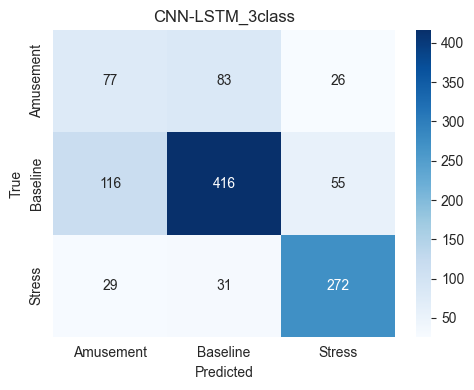


############################################################
# CNN-GRU_3class
############################################################

  S2 held out ...
    epoch   1/80  loss=0.7019
    epoch  10/80  loss=0.3367
    epoch  20/80  loss=0.2002
    epoch  30/80  loss=0.1839
    epoch  40/80  loss=0.1223
    epoch  50/80  loss=0.0715
    epoch  60/80  loss=0.0812
    epoch  70/80  loss=0.0694
    epoch  80/80  loss=0.0698
    => acc=0.930  f1=0.904

  S3 held out ...
    epoch   1/80  loss=0.6723
    epoch  10/80  loss=0.2623
    epoch  20/80  loss=0.1886
    epoch  30/80  loss=0.1028
    epoch  40/80  loss=0.1135
    epoch  50/80  loss=0.0733
    epoch  60/80  loss=0.0817
    epoch  70/80  loss=0.0729
    epoch  80/80  loss=0.0796
    => acc=0.658  f1=0.592

  S4 held out ...
    epoch   1/80  loss=0.6855
    epoch  10/80  loss=0.2757
    epoch  20/80  loss=0.1678
    epoch  30/80  loss=0.1386
    epoch  40/80  loss=0.0857
    epoch  50/80  loss=0.0754
    epoch  60/80  loss=0.0869

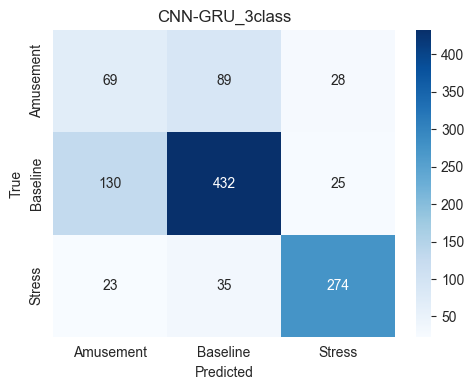


############################################################
# CNN-LSTM-Attention_3class
############################################################

  S2 held out ...
    epoch   1/80  loss=0.6793
    epoch  10/80  loss=0.2812
    epoch  20/80  loss=0.2148
    epoch  30/80  loss=0.1764
    epoch  40/80  loss=0.1267
    epoch  50/80  loss=0.1019
    epoch  60/80  loss=0.1545
    epoch  70/80  loss=0.0436
    epoch  80/80  loss=0.0806
    => acc=0.817  f1=0.768

  S3 held out ...
    epoch   1/80  loss=0.6297
    epoch  10/80  loss=0.2627
    epoch  20/80  loss=0.1404
    epoch  30/80  loss=0.1237
    epoch  40/80  loss=0.1228
    epoch  50/80  loss=0.1373
    epoch  60/80  loss=0.0729
    epoch  70/80  loss=0.0989
    epoch  80/80  loss=0.0727
    => acc=0.603  f1=0.530

  S4 held out ...
    epoch   1/80  loss=0.6829
    epoch  10/80  loss=0.2752
    epoch  20/80  loss=0.1868
    epoch  30/80  loss=0.1881
    epoch  40/80  loss=0.1314
    epoch  50/80  loss=0.1546
    epoch  60/80  

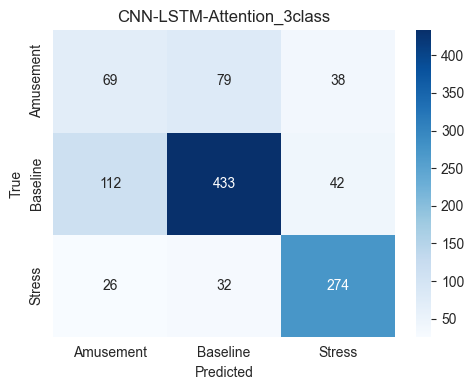


############################################################
# MultiScale-LSTM_3class
############################################################

  S2 held out ...
    epoch   1/80  loss=0.7611
    epoch  10/80  loss=0.3307
    epoch  20/80  loss=0.2496
    epoch  30/80  loss=0.2209
    epoch  40/80  loss=0.1889
    epoch  50/80  loss=0.1288
    epoch  60/80  loss=0.0897
    epoch  70/80  loss=0.1215
    epoch  80/80  loss=0.1329
    => acc=0.803  f1=0.755

  S3 held out ...
    epoch   1/80  loss=0.6955
    epoch  10/80  loss=0.3247
    epoch  20/80  loss=0.2344
    epoch  30/80  loss=0.1708
    epoch  40/80  loss=0.1316
    epoch  50/80  loss=0.1036
    epoch  60/80  loss=0.0802
    epoch  70/80  loss=0.1145
    epoch  80/80  loss=0.0700
    => acc=0.438  f1=0.412

  S4 held out ...
    epoch   1/80  loss=0.7097
    epoch  10/80  loss=0.2917
    epoch  20/80  loss=0.2277
    epoch  30/80  loss=0.1990
    epoch  40/80  loss=0.1756
    epoch  50/80  loss=0.1289
    epoch  60/80  los

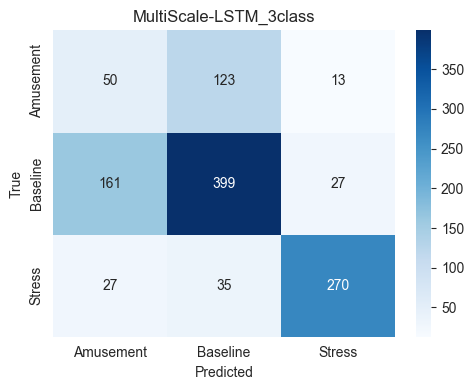


############################################################
# ResNet-LSTM_3class
############################################################

  S2 held out ...
    epoch   1/80  loss=0.6903
    epoch  10/80  loss=0.3738
    epoch  20/80  loss=0.2457
    epoch  30/80  loss=0.1944
    epoch  40/80  loss=0.1467
    epoch  50/80  loss=0.1204
    epoch  60/80  loss=0.0791
    epoch  70/80  loss=0.1545
    epoch  80/80  loss=0.0739
    => acc=0.915  f1=0.864

  S3 held out ...
    epoch   1/80  loss=0.6725
    epoch  10/80  loss=0.3135
    epoch  20/80  loss=0.2384
    epoch  30/80  loss=0.1643
    epoch  40/80  loss=0.1211
    epoch  50/80  loss=0.0987
    epoch  60/80  loss=0.0808
    epoch  70/80  loss=0.1379
    epoch  80/80  loss=0.0842
    => acc=0.603  f1=0.586

  S4 held out ...
    epoch   1/80  loss=0.6378
    epoch  10/80  loss=0.3601
    epoch  20/80  loss=0.2692
    epoch  30/80  loss=0.1836
    epoch  40/80  loss=0.1818
    epoch  50/80  loss=0.1306
    epoch  60/80  loss=0.

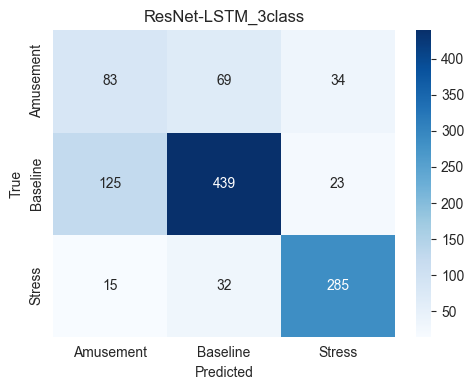

In [14]:
if pkl_available:
    for name, cls, kw in MODELS:
        key = f'{name}_3class'
        print(f'\n{"#"*60}')
        print(f'# {key}')
        print(f'{"#"*60}')
        res = loso_run(subject_data, cls, num_classes=3, binary=False,
                       lr=1e-3, epochs=80, batch_size=16, verbose_every=10, **kw)
        all_results[key] = res
        print_results(key, res, MULTI_NAMES)
        plot_confusion(res, key, MULTI_NAMES)

### 4.2 — Binary (Stress vs Rest)


############################################################
# CNN-LSTM_binary
############################################################

  S2 held out ...
    epoch   1/80  loss=0.3268
    epoch  10/80  loss=0.1852
    epoch  20/80  loss=0.1385
    epoch  30/80  loss=0.0715
    epoch  40/80  loss=0.0656
    epoch  50/80  loss=0.0220
    epoch  60/80  loss=0.0363
    epoch  70/80  loss=0.0192
    epoch  80/80  loss=0.0147
    => acc=0.887  f1=0.874

  S3 held out ...
    epoch   1/80  loss=0.2929
    epoch  10/80  loss=0.0908
    epoch  20/80  loss=0.0801
    epoch  30/80  loss=0.0393
    epoch  40/80  loss=0.0401
    epoch  50/80  loss=0.0339
    epoch  60/80  loss=0.0710
    epoch  70/80  loss=0.0294
    epoch  80/80  loss=0.0303
    => acc=0.685  f1=0.598

  S4 held out ...
    epoch   1/80  loss=0.3386
    epoch  10/80  loss=0.1230
    epoch  20/80  loss=0.0822
    epoch  30/80  loss=0.0425
    epoch  40/80  loss=0.0546
    epoch  50/80  loss=0.0244
    epoch  60/80  loss=0.047

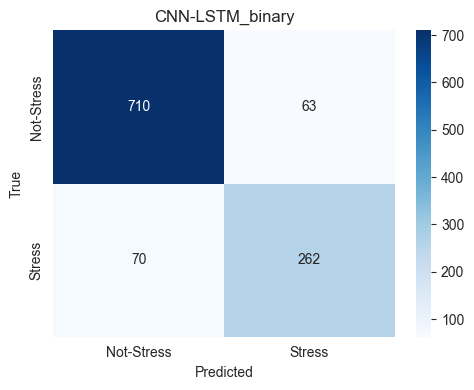


############################################################
# CNN-GRU_binary
############################################################

  S2 held out ...
    epoch   1/80  loss=0.3196
    epoch  10/80  loss=0.1277
    epoch  20/80  loss=0.0573
    epoch  30/80  loss=0.0302
    epoch  40/80  loss=0.0085
    epoch  50/80  loss=0.0147
    epoch  60/80  loss=0.0191
    epoch  70/80  loss=0.0138
    epoch  80/80  loss=0.0401
    => acc=0.944  f1=0.936

  S3 held out ...
    epoch   1/80  loss=0.2793
    epoch  10/80  loss=0.0569
    epoch  20/80  loss=0.0577
    epoch  30/80  loss=0.0480
    epoch  40/80  loss=0.0232
    epoch  50/80  loss=0.0072
    epoch  60/80  loss=0.0279
    epoch  70/80  loss=0.0095
    epoch  80/80  loss=0.0128
    => acc=0.753  f1=0.680

  S4 held out ...
    epoch   1/80  loss=0.2957
    epoch  10/80  loss=0.1048
    epoch  20/80  loss=0.0389
    epoch  30/80  loss=0.0073
    epoch  40/80  loss=0.0075
    epoch  50/80  loss=0.0034
    epoch  60/80  loss=0.0099

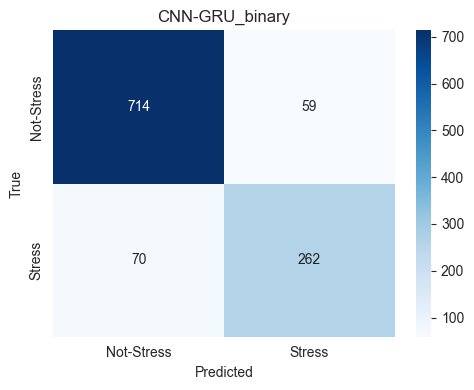


############################################################
# CNN-LSTM-Attention_binary
############################################################

  S2 held out ...
    epoch   1/80  loss=0.3314
    epoch  10/80  loss=0.0770
    epoch  20/80  loss=0.0572
    epoch  30/80  loss=0.0467
    epoch  40/80  loss=0.0281
    epoch  50/80  loss=0.0111
    epoch  60/80  loss=0.0234
    epoch  70/80  loss=0.0201
    epoch  80/80  loss=0.0259
    => acc=0.831  f1=0.815

  S3 held out ...
    epoch   1/80  loss=0.2823
    epoch  10/80  loss=0.0610
    epoch  20/80  loss=0.0449
    epoch  30/80  loss=0.0255
    epoch  40/80  loss=0.0260
    epoch  50/80  loss=0.0213
    epoch  60/80  loss=0.0103
    epoch  70/80  loss=0.0134
    epoch  80/80  loss=0.0207
    => acc=0.603  f1=0.563

  S4 held out ...
    epoch   1/80  loss=0.3311
    epoch  10/80  loss=0.0865
    epoch  20/80  loss=0.0708
    epoch  30/80  loss=0.0329
    epoch  40/80  loss=0.0449
    epoch  50/80  loss=0.0179
    epoch  60/80  

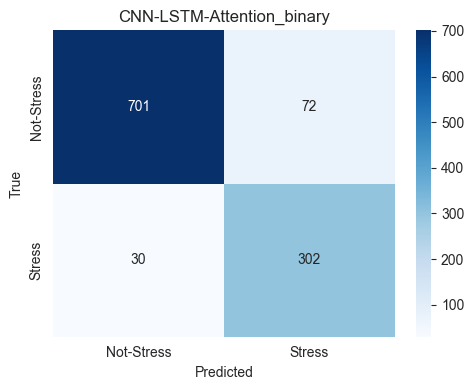


############################################################
# MultiScale-LSTM_binary
############################################################

  S2 held out ...
    epoch   1/80  loss=0.3168
    epoch  10/80  loss=0.1172
    epoch  20/80  loss=0.0655
    epoch  30/80  loss=0.0743
    epoch  40/80  loss=0.0287
    epoch  50/80  loss=0.0131
    epoch  60/80  loss=0.0134
    epoch  70/80  loss=0.0213
    epoch  80/80  loss=0.0307
    => acc=0.986  f1=0.983

  S3 held out ...
    epoch   1/80  loss=0.2987
    epoch  10/80  loss=0.1114
    epoch  20/80  loss=0.0360
    epoch  30/80  loss=0.0487
    epoch  40/80  loss=0.0339
    epoch  50/80  loss=0.0300
    epoch  60/80  loss=0.0164
    epoch  70/80  loss=0.0249
    epoch  80/80  loss=0.0067
    => acc=0.808  f1=0.766

  S4 held out ...
    epoch   1/80  loss=0.3473
    epoch  10/80  loss=0.1130
    epoch  20/80  loss=0.0750
    epoch  30/80  loss=0.0403
    epoch  40/80  loss=0.0370
    epoch  50/80  loss=0.0183
    epoch  60/80  los

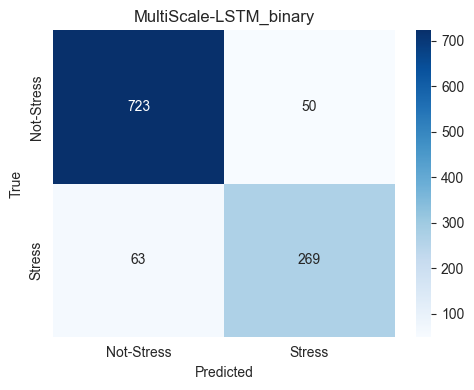


############################################################
# ResNet-LSTM_binary
############################################################

  S2 held out ...
    epoch   1/80  loss=0.3335
    epoch  10/80  loss=0.1707
    epoch  20/80  loss=0.0526
    epoch  30/80  loss=0.0475
    epoch  40/80  loss=0.0468
    epoch  50/80  loss=0.0185
    epoch  60/80  loss=0.0141
    epoch  70/80  loss=0.0199
    epoch  80/80  loss=0.0104
    => acc=0.958  f1=0.951

  S3 held out ...
    epoch   1/80  loss=0.3186
    epoch  10/80  loss=0.1156
    epoch  20/80  loss=0.1187
    epoch  30/80  loss=0.0713
    epoch  40/80  loss=0.0571
    epoch  50/80  loss=0.0238
    epoch  60/80  loss=0.0319
    epoch  70/80  loss=0.0027
    epoch  80/80  loss=0.0180
    => acc=0.658  f1=0.588

  S4 held out ...
    epoch   1/80  loss=0.3569
    epoch  10/80  loss=0.1464
    epoch  20/80  loss=0.0657
    epoch  30/80  loss=0.0507
    epoch  40/80  loss=0.0522
    epoch  50/80  loss=0.0227
    epoch  60/80  loss=0.

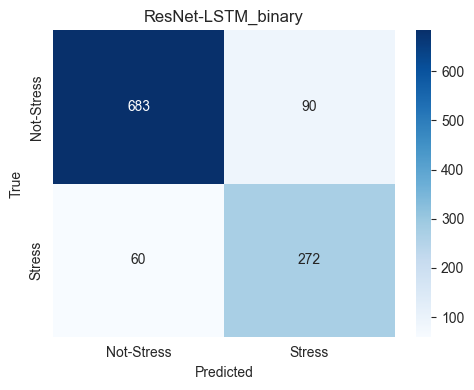

In [15]:
if pkl_available:
    for name, cls, kw in MODELS:
        key = f'{name}_binary'
        print(f'\n{"#"*60}')
        print(f'# {key}')
        print(f'{"#"*60}')
        res = loso_run(subject_data, cls, num_classes=2, binary=True,
                       lr=1e-3, epochs=80, batch_size=16, verbose_every=10, **kw)
        all_results[key] = res
        print_results(key, res, BIN_NAMES)
        plot_confusion(res, key, BIN_NAMES)

---
## 5 — Final Comparison

In [16]:
rows = []
for key, res in all_results.items():
    rows.append({
        'Model': key,
        'Mean Acc': f"{res['mean_acc']:.3f} +/- {res['std_acc']:.3f}",
        'Mean F1':  f"{res['mean_f1']:.3f} +/- {res['std_f1']:.3f}",
    })
summary = pd.DataFrame(rows)
summary

,Model,Mean Acc,Mean F1
0,CNN-LSTM_3class,0.693 +/- 0.177,0.634 +/- 0.190
1,CNN-GRU_3class,0.702 +/- 0.175,0.639 +/- 0.193
2,CNN-LSTM-Attention_3class,0.703 +/- 0.176,0.627 +/- 0.187
3,MultiScale-LSTM_3class,0.651 +/- 0.160,0.575 +/- 0.146
4,ResNet-LSTM_3class,0.731 +/- 0.155,0.667 +/- 0.180
5,CNN-LSTM_binary,0.881 +/- 0.169,0.854 +/- 0.206
6,CNN-GRU_binary,0.885 +/- 0.178,0.861 +/- 0.210
7,CNN-LSTM-Attention_binary,0.908 +/- 0.131,0.897 +/- 0.145
8,MultiScale-LSTM_binary,0.899 +/- 0.167,0.879 +/- 0.190
9,ResNet-LSTM_binary,0.866 +/- 0.170,0.846 +/- 0.187


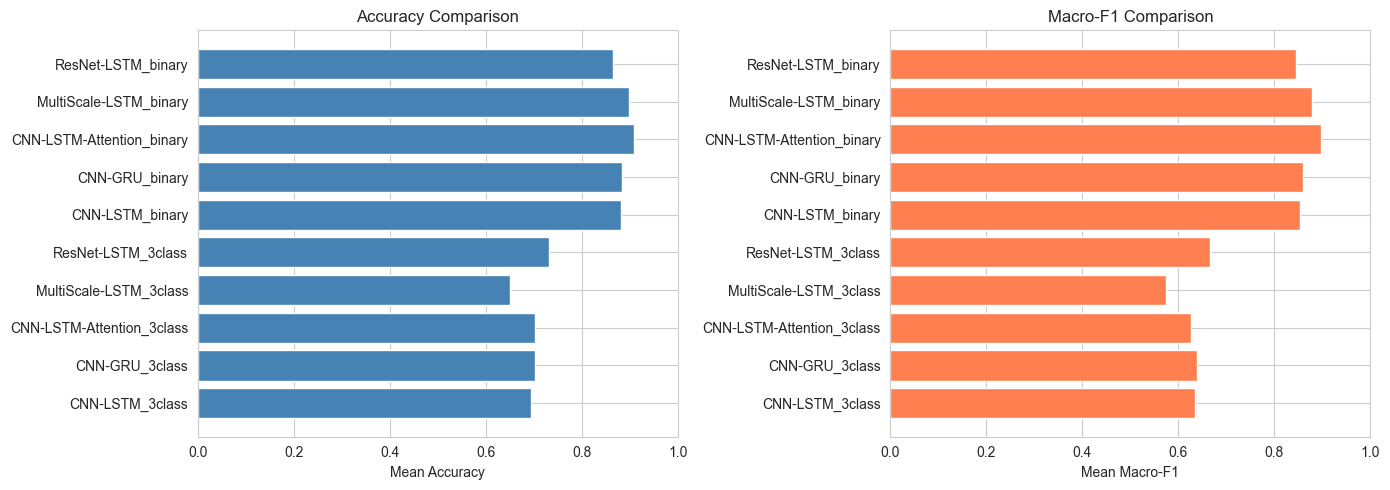

In [17]:
if all_results:
    names = list(all_results.keys())
    accs = [all_results[k]['mean_acc'] for k in names]
    f1s = [all_results[k]['mean_f1'] for k in names]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(names, accs, color='steelblue')
    axes[0].set_xlabel('Mean Accuracy')
    axes[0].set_title('Accuracy Comparison')
    axes[0].set_xlim(0, 1)
    axes[1].barh(names, f1s, color='coral')
    axes[1].set_xlabel('Mean Macro-F1')
    axes[1].set_title('Macro-F1 Comparison')
    axes[1].set_xlim(0, 1)
    plt.tight_layout()
    plt.show()